# Cubagem Multimodal

MLP com embeddings pré-computados


## 0. Drive e verificação de GPU

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Imports e configuração

In [70]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

In [3]:
df = pd.read_csv("../data/cubagem_40k_amazon.csv")
df.columns

Index(['asin', 'title', 'main_category', 'source_category', 'categories',
       'store', 'length_cm', 'width_cm', 'height_cm', 'weight_g', 'volume_cm3',
       'density_g_cm3', 'log_volume', 'log_weight', 'dim_max_cm', 'dim_min_cm',
       'dim_ratio', 'price_raw', 'price_numeric', 'log_price', 'avg_rating',
       'n_ratings', 'n_images', 'title_length', 'title_word_count',
       'has_dim_in_title', 'has_size_word_in_title', 'has_qty_in_title',
       'description', 'description_length', 'n_categories_levels', 'image_url',
       'split'],
      dtype='str')

In [4]:
features = {
    "categorical": [
        "main_category",
        "source_category",
        # Leaving those out because I dont want to deal with high cardinality now
        # "categories",
        # "store",
    ],
    "text": [
        "title",
        "description",
    ],
    "numerical": [
        "price_numeric",
        "avg_rating",
        "n_ratings",
        "n_images",
        "title_length",
        "title_word_count",
        "description_length",
        "n_categories_levels",
    ],
    "title_regex": [
        "has_dim_in_title",
        "has_size_word_in_title",
        "has_qty_in_title",
    ],
    "image": [
        "image_url",
    ],
}

targets = [
    "length_cm",   # length >= width >= height
    "width_cm",
    "height_cm",
    "weight_g",
]

log_targets = [
    "log_length_cm",   # length >= width >= height
    "log_width_cm",
    "log_height_cm",
    "log_weight_g",
]

In [438]:
class LogTransform:
    def __init__(self, c, name):
        self.c = c
        self.name = name

    def __str__(self):
        return self.name

    def f(self, x):
        return np.log(x + self.c)

    def inv(self, x):
        return np.exp(x) - self.c

c = 5
transform = LogTransform(c, f"log(x+{c})")

In [439]:
df[log_targets] = transform.f(df[targets])

In [440]:
ROOT = "../embeddings"

EMBEDDINGS = {
    "texto_train"  : f"{ROOT}/texto_train.npy",
    "texto_val"    : f"{ROOT}/texto_val.npy",
    "imagem_train" : f"{ROOT}/imagem_train.npy",
    "imagem_val"   : f"{ROOT}/imagem_val.npy",
}

## Dados e feature engineering

In [441]:
df = df.dropna(subset=targets + ["title", "image_url"])
df[features["title_regex"]] = df[features["title_regex"]].fillna(False).astype(float)

In [442]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode(df, cols, drop_first=False):
    encoder = OneHotEncoder(
        sparse_output=False,
        drop="first" if drop_first else None,
        handle_unknown="ignore",  # unseen category at inference -> all zeros, no crash
    )
 
    encoded = encoder.fit_transform(df[cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(cols),
        index=df.index,
    )
 
    df_out = df.drop(columns=cols).join(encoded_df)
    return df_out, encoder
 
def apply_one_hot_encode(df, cols, encoder):
    encoded = encoder.transform(df[cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(cols),
        index=df.index,
    )
    return df.drop(columns=cols).join(encoded_df)

In [443]:
df_encoded, encoder = one_hot_encode(df, features["categorical"])
OHE_columns = [x for x in df_encoded.columns if x not in df.columns]

In [444]:
df_train = df_encoded[df_encoded["split"] == "train"].reset_index(drop=True)
df_val   = df_encoded[df_encoded["split"] == "val"  ].reset_index(drop=True)

print(f"Treino: {len(df_train):,} | Val: {len(df_val):,}")

Treino: 31,986 | Val: 7,999


In [445]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10, random_state=42)
# Fit and transform on train
df_train[features["numerical"]] = imputer.fit_transform(df_train[features["numerical"]])
# Just transform on val
df_val[features["numerical"]] = imputer.transform(df_val[features["numerical"]])

## Carrega Embeddings

In [446]:
class CubagemDataset(Dataset):
    def __init__(self, df, text_npz_path, img_npz_path, features_columns, targets_columns):
        self.df = df.reset_index(drop=True)
        self.asins = self.df["asin"].values
        
        # Load embeddings
        text_data = np.load(text_npz_path, allow_pickle=True)
        img_data  = np.load(img_npz_path, allow_pickle=True)
        
        self.text_dict = dict(zip(text_data["asins"], text_data["embeddings"]))
        self.img_dict  = dict(zip(img_data["asins"], img_data["embeddings"]))
        
        self.features   = torch.tensor(self.df[features_columns].values, dtype=torch.float32)
        self.targets     = torch.tensor(self.df[targets_columns].values, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        asin = self.asins[idx]
        
        # Fetch embeddings dynamically
        emb_t = self.text_dict.get(asin, np.zeros(768, dtype=np.float32))
        emb_i = self.img_dict.get(asin, np.zeros(768, dtype=np.float32))
        
        return {
            "emb_texto":   torch.tensor(emb_t, dtype=torch.float32),
            "emb_img":     torch.tensor(emb_i, dtype=torch.float32),
            "features":    self.features[idx],
            "targets":     self.targets[idx],
        }

Create dataloaders

In [447]:
BATCH_SIZE = 32

features_columns = features["numerical"] + OHE_columns + features["title_regex"]

def create_loaders(df_tr, df_vl, text_npz_path="../embeddings/text_embeddings.npz", img_npz_path="../embeddings/imagem_embeddings.npz"):
    ds_tr = CubagemDataset(df_tr, text_npz_path=text_npz_path, img_npz_path=img_npz_path, features_columns=features_columns, targets_columns=log_targets)
    ds_vl = CubagemDataset(df_vl, text_npz_path=text_npz_path, img_npz_path=img_npz_path, features_columns=features_columns, targets_columns=log_targets)
    
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE,
                       shuffle=True,  num_workers=2, pin_memory=True)
    dl_vl = DataLoader(ds_vl, batch_size=BATCH_SIZE,
                       shuffle=False, num_workers=2, pin_memory=True)
    return dl_tr, dl_vl

Create the 2-layer MLP

In [448]:
class CubagemMLP(nn.Module):
    """
    Two-layer MLP predicting 4 targets (3 dimensions + weight, in log space)
    from concatenated image/text embeddings + numerical/categorical/regex feats.
    """
    def __init__(
        self,
        emb_texto_dim,
        emb_img_dim,
        feats_dim,
        hidden_dim=1024,
        n_targets=4,
        dropout=0.5,
    ):
        super().__init__()
 
        input_dim = emb_texto_dim + emb_img_dim + feats_dim
        
        self.net = nn.Sequential(
            # nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//4, n_targets),
        )
 
    def forward(self, batch):
        x = torch.cat(
            [
                batch["emb_texto"],
                batch["emb_img"],
                batch["features"],
            ],
            dim=1,
        )
        return self.net(x)

Training helper functions

In [449]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ExponentialLR

class RMSELoss(torch.nn.Module):
    def __init__(self):
        super(RMSELoss,self).__init__()

    def forward(self,x,y):
        criterion = nn.MSELoss()
        loss = torch.sqrt(criterion(x, y))
        return loss

def move_batch_to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    n_batches = 0
 
    for batch in loader:
        batch = move_batch_to_device(batch, device)
        targets = batch["targets"]
 
        optimizer.zero_grad()
        preds = model(batch)
        loss = loss_fn(preds, targets)  # MSE
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item()
        n_batches += 1
 
    return total_loss / n_batches

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0
 
    for batch in loader:
        batch = move_batch_to_device(batch, device)
        targets = batch["targets"]
 
        preds = model(batch)
        loss = loss_fn(preds, targets)
  
        total_loss += loss.item()
        n_batches += 1
 
    return total_loss / n_batches

def train(
    model,
    train_loader,
    val_loader,
    n_epochs=50,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    device=None,
    patience=3
):
    """
    Training loop.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
  
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ExponentialLR(optimizer, gamma=0.7)
    loss_fn = RMSELoss()
 
    history = []
    best_val_rmse = float("inf")
    best_state_dict = None
 
    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss = evaluate(model, val_loader, loss_fn, device)
        scheduler.step()
 
        history.append(
            {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss}
        )
 
        # Track best RMSE and save weights
        if val_loss < best_val_rmse:
            best_val_rmse = val_loss
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
 
        # Print logs
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d} | "
                f"train loss (RMSE): {train_loss:.4f} | "
                f"val loss (RMSE): {val_loss:.4f} | "
            )

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break
 
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
 
    return model, history

In [450]:
dl_train, dl_val = create_loaders(df_train, df_val)

dims = dict(
    emb_texto_dim=768,
    emb_img_dim=768,
    feats_dim=len(features["numerical"]) + len(OHE_columns) + len(features["title_regex"])
)

model = CubagemMLP(**dims)

trained_model, history = train(
    model, dl_train, dl_val, n_epochs=100, batch_size=16, lr=1e-3,
)

Epoch   1 | train loss (RMSE): 1.7534 | val loss (RMSE): 0.7152 | 
Epoch   5 | train loss (RMSE): 0.7517 | val loss (RMSE): 0.5840 | 
Epoch  10 | train loss (RMSE): 0.6480 | val loss (RMSE): 0.5597 | 
Epoch  15 | train loss (RMSE): 0.6237 | val loss (RMSE): 0.5487 | 
Early stopping at epoch 18.


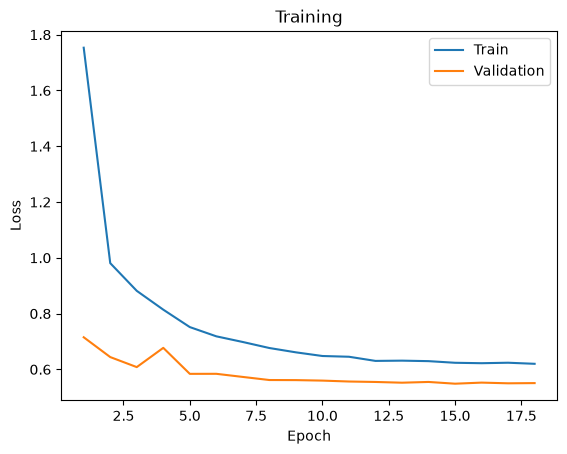

In [451]:
plt.plot(
    [x["epoch"] for x in history],
    [x["train_loss"] for x in history],
    label="Train"
)

plt.plot(
    [x["epoch"] for x in history],
    [x["val_loss"] for x in history],
    label="Validation"
)
plt.title("Training")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [452]:
# Saving the model weights
torch.save(trained_model.state_dict(), "../weights/CubagemMLP.pth")

In [453]:
# Load the model
saved_weights = torch.load("../weights/CubagemMLP.pth")

model = CubagemMLP(**dims)
model.load_state_dict(saved_weights)

<All keys matched successfully>

O que ainda precisa fazer? Checar esse valor de MSE e plotar os graficos, alem de conferir na mao se tudo esta certo

In [454]:
@torch.no_grad()
def evaluate_and_stratify(model, val_loader, device, target_names, log_scale=True, n_buckets=10):
    model.eval() # Set model to eval
    
    all_preds = []
    all_targets = []
    
    # Collect all predictions and actuals
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        preds = model(batch)
        targets = batch["targets"]
        
        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    if not log_scale:
        all_preds = transform.inv(all_preds)
        all_targets = transform.inv(all_targets)
    
    # Error dataframe
    df_list = []
    num_targets = all_targets.shape[1]
    
    for i in range(num_targets):
        t_name = target_names[i]
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]
        

        # target dict
        target_dict = {
            "target": t_name,
            "y_true": y_true,
            "y_pred": y_pred,
        }

        if not log_scale:
            mae = np.abs(y_true - y_pred)
            mape = (mae / (np.abs(y_true) + 1e-8)) * 100
            buckets = pd.qcut(y_true, q=n_buckets, duplicates="drop")
            target_dict.update({
                "mae": mae,
                "mape": mape,
                "bucket": buckets
            })
        
        df_list.append(pd.DataFrame(target_dict))
        
    # Combine all targets into one massive dataframe
    df_errors = pd.concat(df_list, ignore_index=True)
    
    return df_errors

In [455]:
def plot_residuals(df_errors):
    """
    Iterates over targets to plot Residuals vs Predicted and the Residual Distribution.
    Requires columns: 'target', 'y_true', 'y_pred'.
    """
    # Calculate residuals (Actual - Predicted)
    df_errors = df_errors.copy()
    df_errors['residual'] = df_errors['y_true'] - df_errors['y_pred']
    
    targets = df_errors['target'].unique()
    n_targets = len(targets)
    
    fig, axes = plt.subplots(nrows=n_targets, ncols=2, figsize=(10, 3 * n_targets), squeeze=False)
    
    for i, target_name in enumerate(targets):
        df_t = df_errors[df_errors['target'] == target_name]
        
        ax_scatter = axes[i, 0]
        ax_hist = axes[i, 1]
        
        # Plot A: Residuals vs Predicted (Checks for homoscedasticity)
        sns.scatterplot(data=df_t, x='y_pred', y='residual', alpha=0.4, ax=ax_scatter)
        ax_scatter.set_title(f"{target_name}: Residuals vs Predicted")
        ax_scatter.set_xlabel("Predicted Value")
        ax_scatter.set_ylabel("Residual (True - Pred)")
        ax_scatter.grid(alpha=0.3)
        
        # Plot B: Residual Distribution (Checks for normality)
        sns.histplot(data=df_t, x='residual', kde=True, bins=30, ax=ax_hist)
        ax_hist.set_title(f"{target_name}: Residual Distribution")
        ax_hist.set_xlabel("Residual")
        ax_hist.grid(alpha=0.3)
        
    plt.tight_layout()
    return fig

In [456]:
def plot_all_stratified_errors(df_errors):
    """
    Boxplots of MAE and MAPE per size bucket for ALL targets.
    Creates a grid with 1 row per target and 2 columns (MAE, MAPE).
    """
    targets = df_errors["target"].unique()
    n_targets = len(targets)
    
    # Create a grid: n_targets rows, 2 columns
    fig, axes = plt.subplots(n_targets, 2, figsize=(20, 4 * n_targets), squeeze=False)
    
    for i, target_name in enumerate(targets):
        df_t = df_errors[df_errors["target"] == target_name].copy()
        
        # Order buckets by their interval's left edge, label with sample count
        bucket_order = sorted(df_t["bucket"].unique(), key=lambda b: b.left)
        counts = df_t["bucket"].value_counts()
        labels = [f"{b}\n(n={counts[b]})" for b in bucket_order]
        
        # Plot MAE (column 0) and MAPE (column 1) for the current target row
        for j, (metric, title) in enumerate(zip(["mae", "mape"], ["MAE (original units)", "MAPE (%)"])):
            ax = axes[i, j]
            data = [df_t[df_t["bucket"] == b][metric].values for b in bucket_order]
            
            ax.boxplot(data, tick_labels=labels, showfliers=False)
            ax.set_title(f"{target_name}: {title} by size bucket")
            ax.set_xlabel("Size bucket (quantile-based)")
            ax.set_ylabel(title)
            ax.tick_params(axis="x", rotation=30)
            ax.grid(axis="y", alpha=0.3)
            
    plt.tight_layout()
    return fig

In [457]:
def compute_overall_metrics(df_errors):
    """
    Computes overall MAE, MAPE, and RMSE for each target in df_errors.
    Requires columns: 'target', 'y_true', 'y_pred'.
    """
    results = []
    
    for target in df_errors['target'].unique():
        df_t = df_errors[df_errors['target'] == target]
        
        y_true = df_t['y_true'].values
        y_pred = df_t['y_pred'].values
        
        # Calculate metrics
        mae = np.mean(np.abs(y_true - y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        
        results.append({
            "Target": target,
            "MAE": mae,
            "MAPE (%)": mape,
            "RMSE": rmse
        })
        
    return pd.DataFrame(results)

In [458]:
model.to(device)

CubagemMLP(
  (net): Sequential(
    (0): Linear(in_features=1598, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=1024, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [459]:
ds_val = CubagemDataset(df_val, text_npz_path="../embeddings/text_embeddings.npz", img_npz_path="../embeddings/imagem_embeddings.npz", features_columns=features_columns, targets_columns=log_targets)    
dataloader_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)

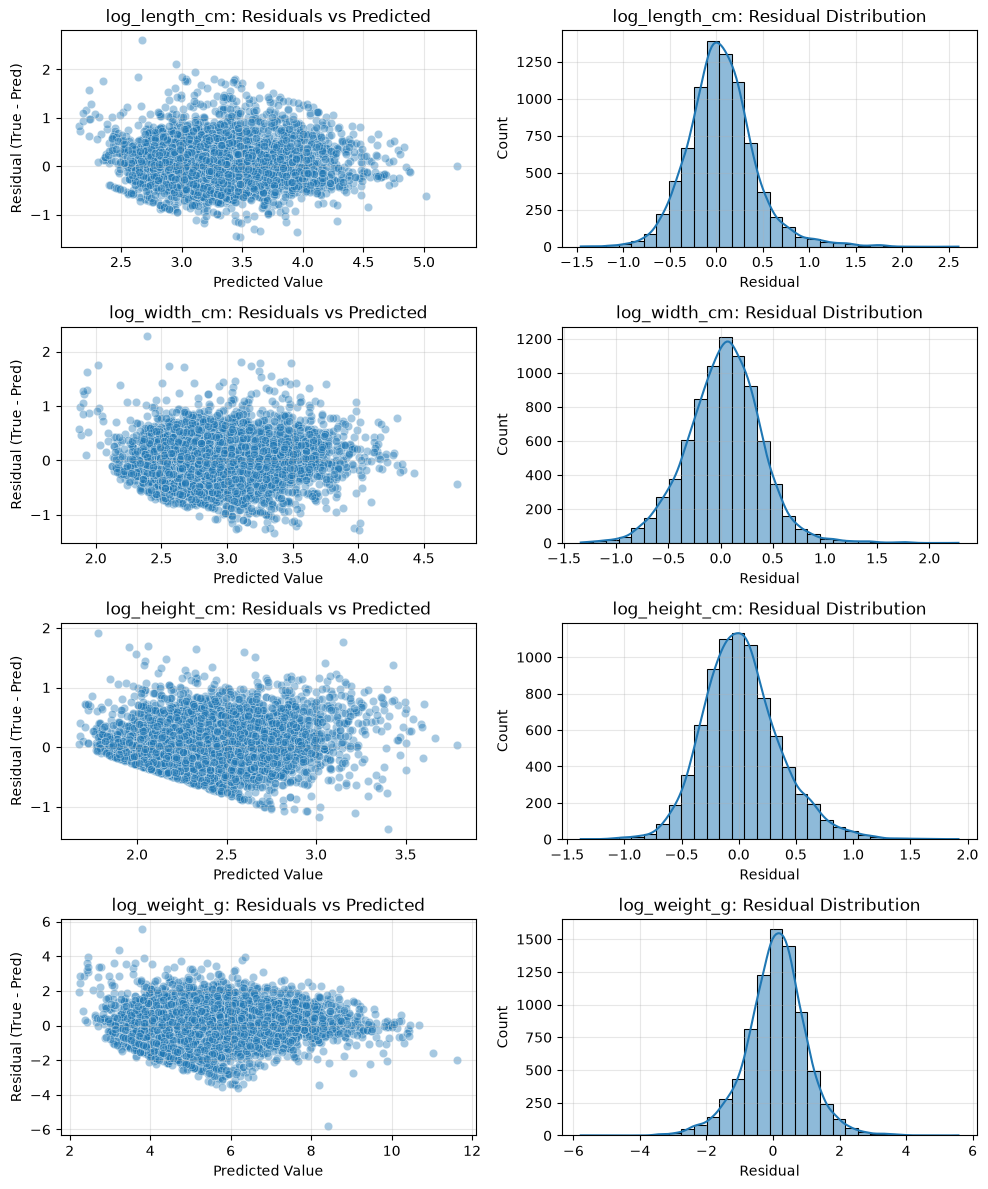

In [460]:
df_errors = evaluate_and_stratify(model, dataloader_val, device, log_targets, log_scale=True)
fig = plot_residuals(df_errors)
fig.savefig(f"../results/log_residuals_{transform}.jpg")

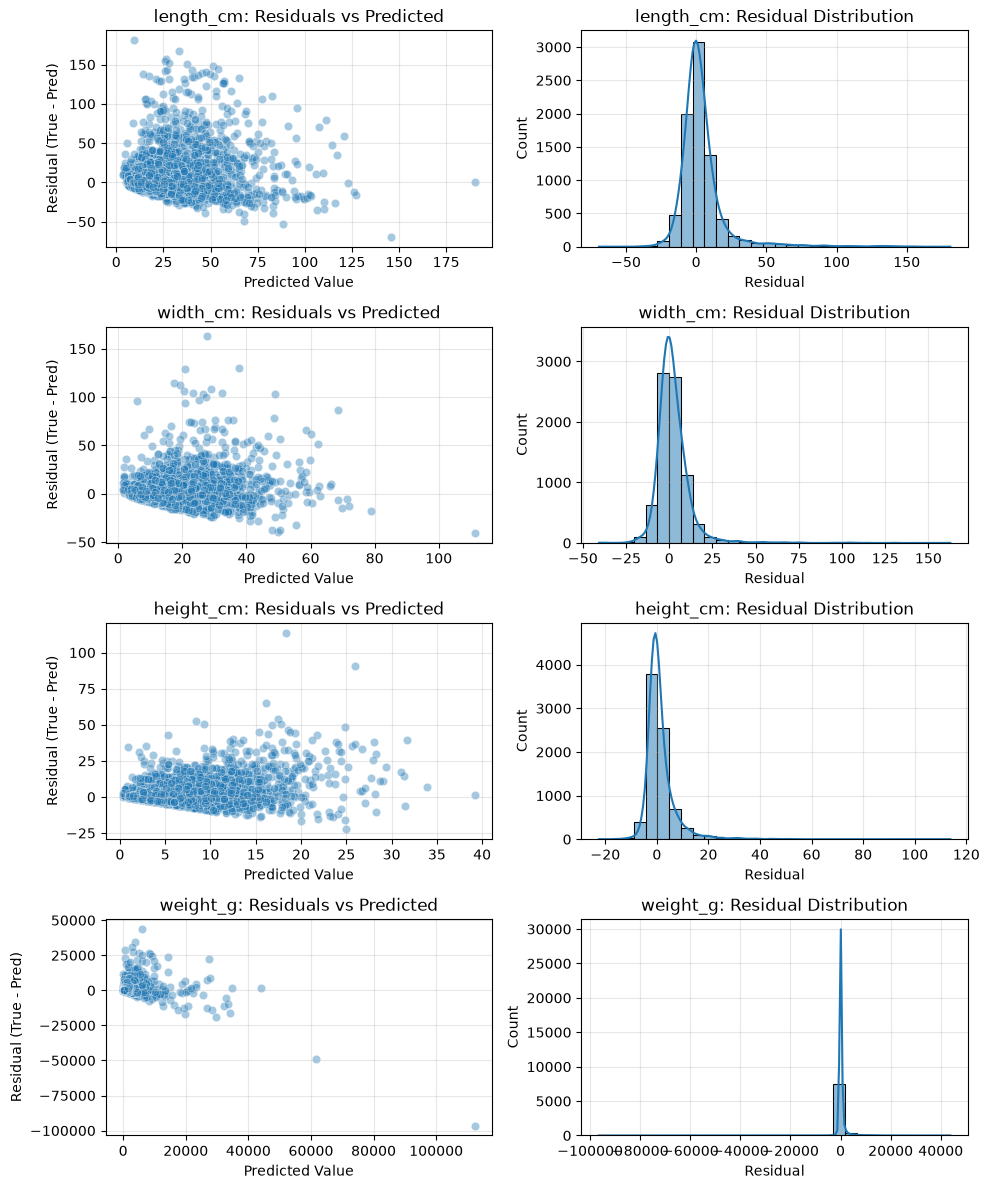

In [461]:
df_errors = evaluate_and_stratify(model, dataloader_val, device, targets, log_scale=False)
plot_residuals(df_errors)
fig.savefig(f"../results/residuals_{transform}.jpg")

In [462]:
results = compute_overall_metrics(df_errors)
results.to_csv(f"../results/metrics_{transform}.csv")
results

,Target,MAE,MAPE (%),RMSE
0,length_cm,9.503074,35.602207,17.734917
1,width_cm,6.263496,47.466122,10.565595
2,height_cm,3.463972,79.538391,6.106565
3,weight_g,559.929932,120.040237,2281.991211


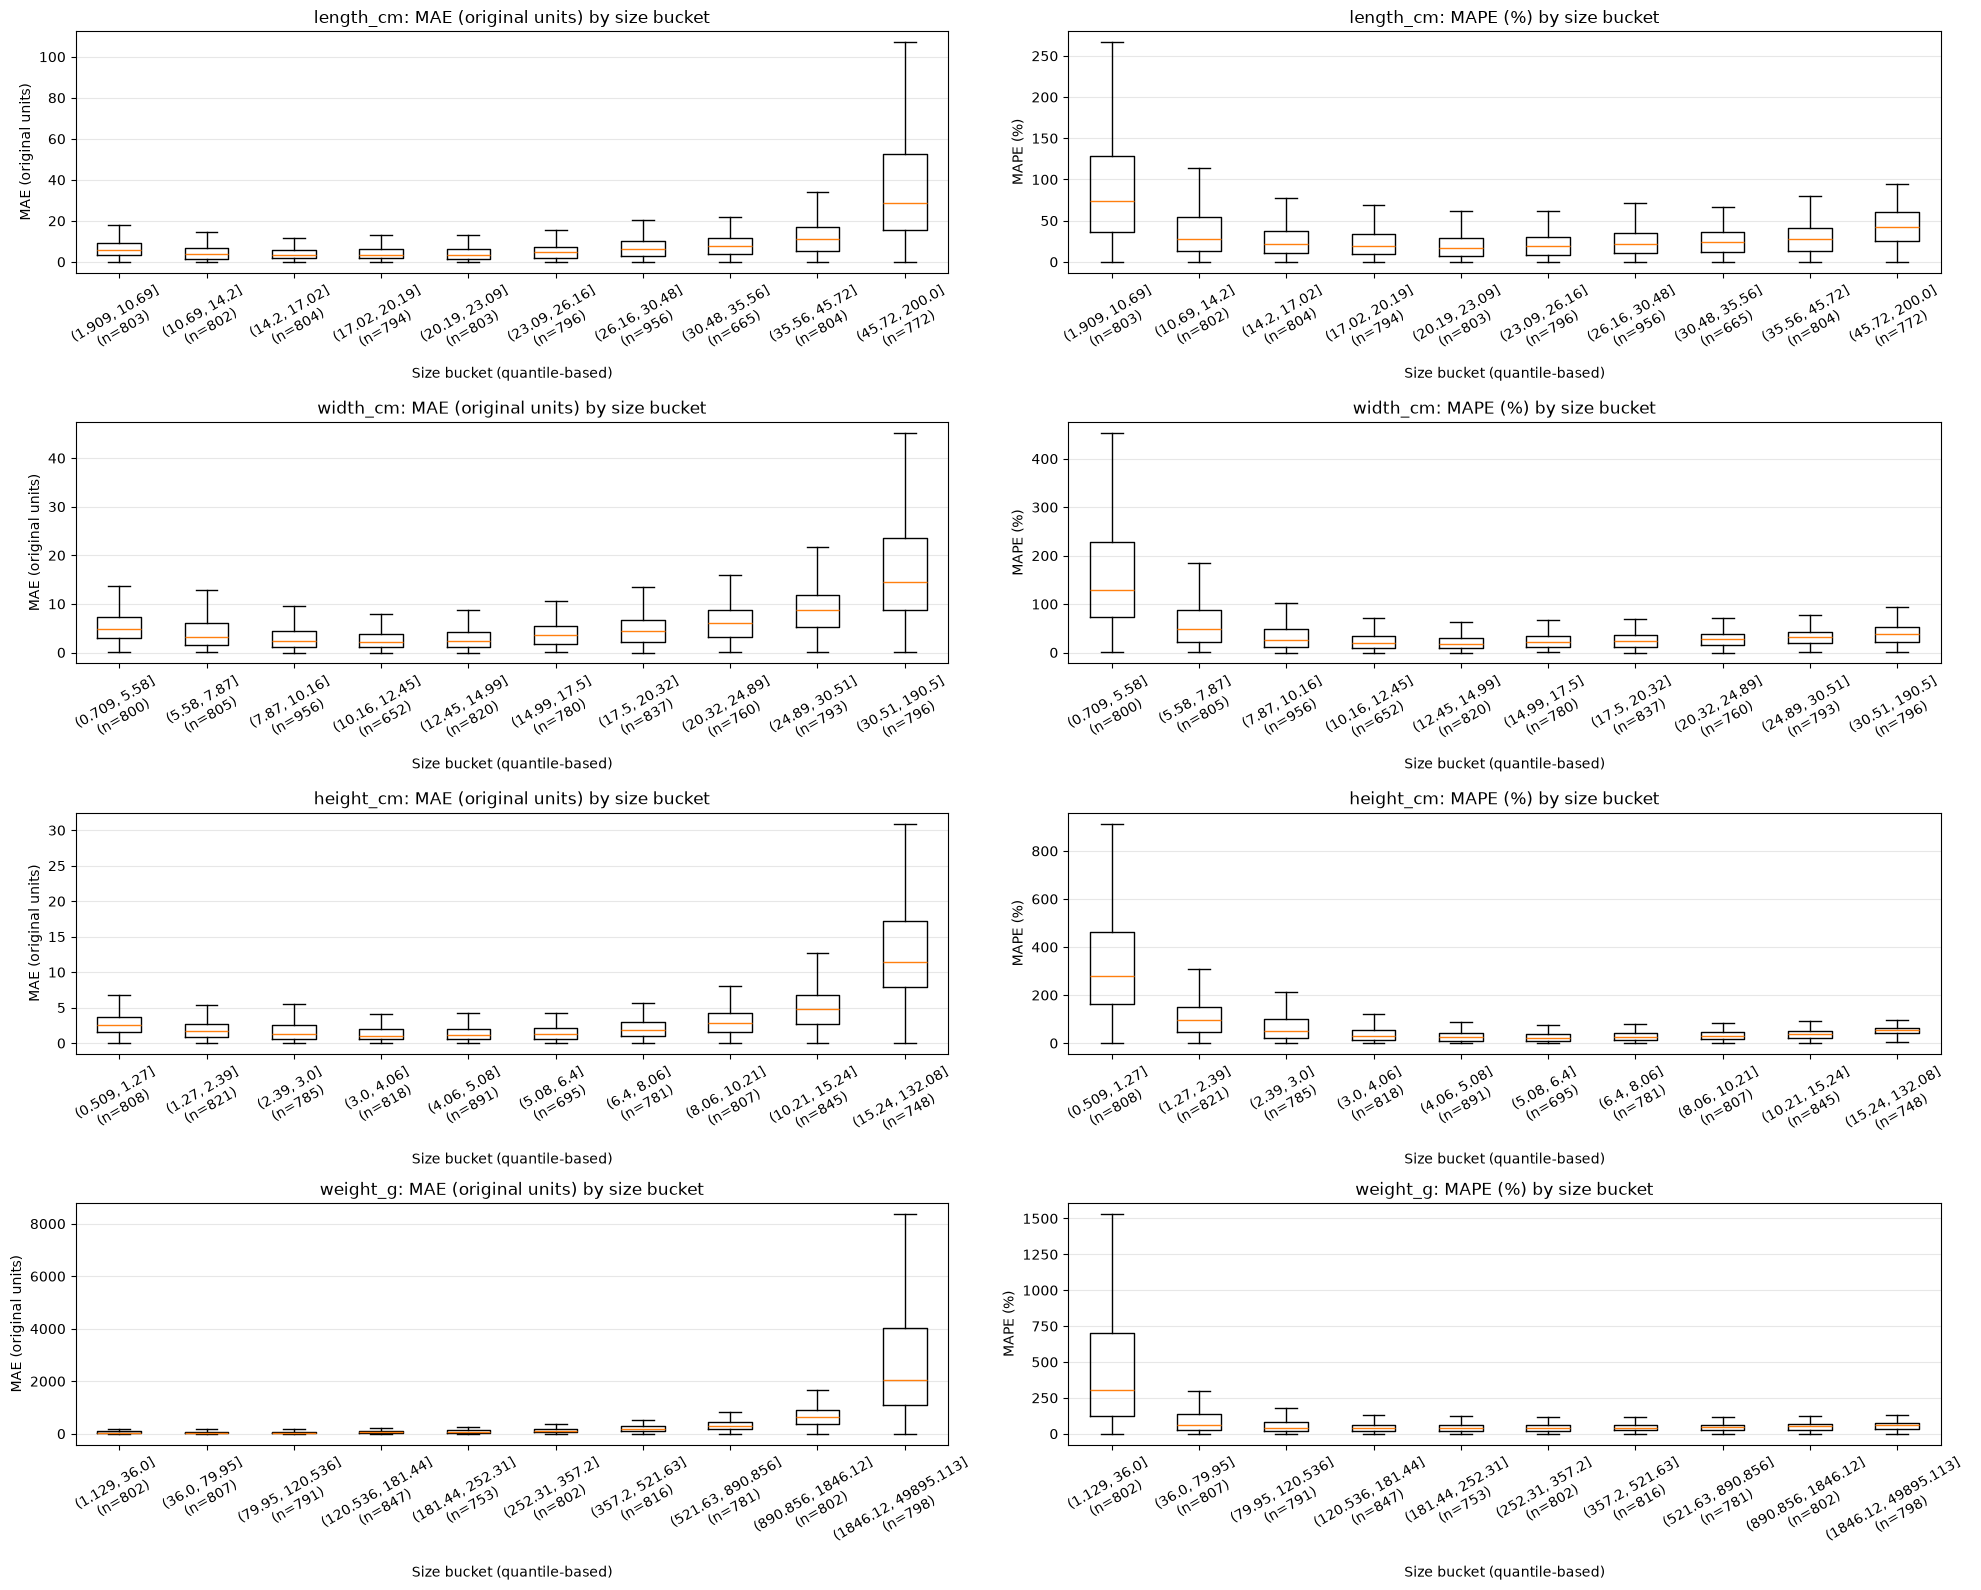

In [463]:
fig = plot_all_stratified_errors(df_errors)
fig.savefig(f"../results/residuals_{transform}.jpg")